<a href="https://colab.research.google.com/github/baanujan-18/Statistical-Learning-e20030/blob/main/Assignment_01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Assignment_01**

# Q1) The Probability of Shooting at a Target

A point is chosen at random from a disk of radius **10**. Let **A** be the event that the point lies within **1** unit of the boundary.

1. Model the experiment assuming the point is uniformly distributed with respect to area, and compute $P(A)$.

# 1. Uniform Distribution Over Area

Let **A** be the event that the point is located within 1 unit from the boundary of the circle.

Using the radius, this region can be written as:

* Outer limit: $r = R$
* Inner limit: $r = R - 1$

Therefore,

* $$A = \{ r : R - 1 \le r \le R \}$$

Since the point is uniformly distributed over the area,

* Area of sample space:

$$
\text{Area}(\Omega) = \pi R^2
$$

* Area of event:

$$
\text{Area}(A) = \pi R^2 - \pi (R - 1)^2
$$

Now,

$$
P(A) = \frac{\text{Area}(A)}{\text{Area}(\Omega)}
$$

$$
P(A) = \frac{\pi R^2 - \pi (R - 1)^2}{\pi R^2}
$$

$$
P(A) = \frac{2R - 1}{R^2}
$$

Given $R = 10$,

$$
P(A) = \frac{2(10)-1}{10^2}
$$

$$
P(A) = 0.19
$$

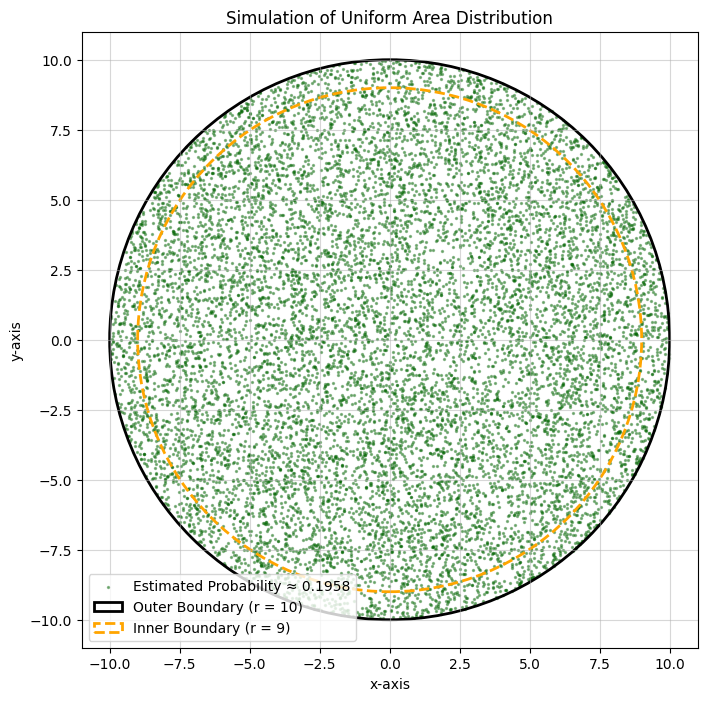

Theoretical Probability = 0.1900
Estimated Probability   = 0.1958


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def area_distribution_simulation(total_points=8000, R=10):

    # Generate random angles
    angles = np.random.uniform(0, 2*np.pi, total_points)

    # Generate radius values for uniform area distribution
    radial_distance = R * np.sqrt(np.random.rand(total_points))

    # Convert polar coordinates into Cartesian coordinates
    x_coord = radial_distance * np.cos(angles)
    y_coord = radial_distance * np.sin(angles)

    # Points lying within 1 unit from the boundary
    boundary_region = radial_distance >= (R - 1)

    # Estimated probability
    estimated_probability = np.mean(boundary_region)

    return x_coord, y_coord, estimated_probability


# Simulation
num_samples = 12000

x_vals, y_vals, estimated_p = area_distribution_simulation(num_samples)

# Plotting
fig, ax = plt.subplots(figsize=(8,8))

scatter_plot = ax.scatter(
    x_vals,
    y_vals,
    s=2,
    alpha=0.4,
    color='darkgreen',
    label=f"Estimated Probability ≈ {estimated_p:.4f}"
)

# Outer circle
outer_circle = plt.Circle(
    (0,0),
    10,
    edgecolor='black',
    fill=False,
    linewidth=2,
    label='Outer Boundary (r = 10)'
)

# Inner circle
inner_circle = plt.Circle(
    (0,0),
    9,
    edgecolor='orange',
    fill=False,
    linestyle='--',
    linewidth=2,
    label='Inner Boundary (r = 9)'
)

ax.add_patch(outer_circle)
ax.add_patch(inner_circle)

ax.set_xlim(-11,11)
ax.set_ylim(-11,11)

ax.set_aspect('equal')

plt.title("Simulation of Uniform Area Distribution")
plt.xlabel("x-axis")
plt.ylabel("y-axis")

plt.grid(alpha=0.5)
plt.legend(loc='lower left')

plt.show()

print(f"Theoretical Probability = 0.1900")
print(f"Estimated Probability   = {estimated_p:.4f}")

## 2. Uniform Distribution with Respect to Radius

In this approach, the radial distance \(r\) is selected uniformly from the interval \([0, R]\), while the angle is chosen independently.  
Therefore, the probability depends on the radial length rather than the area.

* Length of the total sample space:

$$
L(\Omega)=R
$$

* Length corresponding to event \(A\):

$$
L(A)=R-(R-1)
$$

$$
L(A)=1
$$

### Probability Calculation

Using the ratio of lengths,

$$
P(A)=\frac{L(A)}{L(\Omega)}
$$

Substituting the values,

$$
P(A)=\frac{R-(R-1)}{R}
$$

Simplifying,

$$
P(A)=\frac{1}{R}
$$

For the case where \(R=10\),

$$
P(A)=\frac{1}{10}
$$

Therefore,

$$
P(A)=0.1
$$

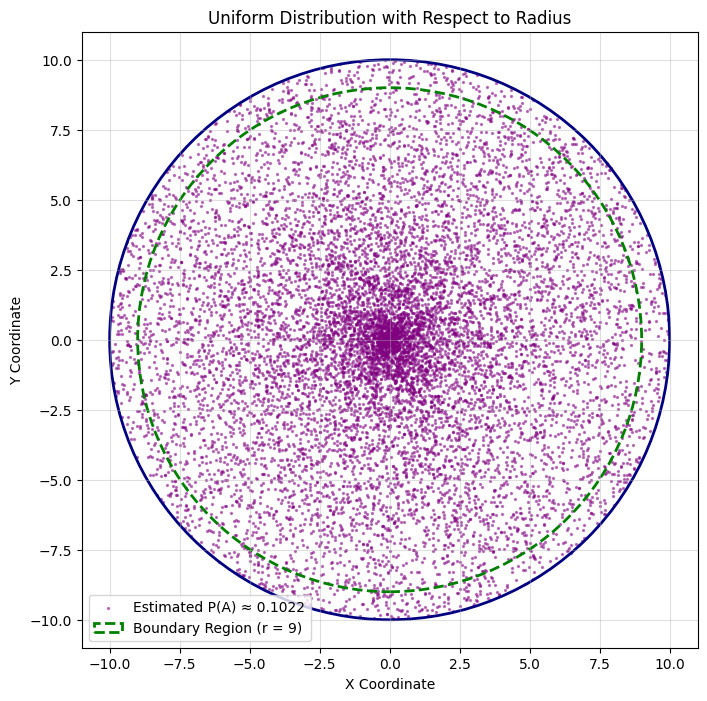

Theoretical Probability = 0.1000
Estimated Probability   = 0.1022


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def radial_distribution_model(sample_size=8000, R=10):

    # Random angle generation
    theta_values = np.random.uniform(0, 2*np.pi, sample_size)

    # Radius selected uniformly from [0, R]
    radius_values = np.random.uniform(0, R, sample_size)

    # Polar to Cartesian conversion
    x_points = radius_values * np.cos(theta_values)
    y_points = radius_values * np.sin(theta_values)

    # Event A : points within 1 unit from the boundary
    event_region = radius_values >= (R - 1)

    # Experimental probability
    probability_estimate = np.mean(event_region)

    return x_points, y_points, probability_estimate


# Run simulation
num_points = 12000

x_data, y_data, estimated_prob = radial_distribution_model(num_points)

# Create figure
fig, ax = plt.subplots(figsize=(8,8))

# Scatter plot
ax.scatter(
    x_data,
    y_data,
    s=2,
    alpha=0.45,
    color='purple',
    label=f"Estimated P(A) ≈ {estimated_prob:.4f}"
)

# Outer boundary
outer_boundary = plt.Circle(
    (0,0),
    10,
    edgecolor='navy',
    fill=False,
    linewidth=2
)

# Inner boundary
inner_boundary = plt.Circle(
    (0,0),
    9,
    edgecolor='green',
    fill=False,
    linestyle='--',
    linewidth=2,
    label='Boundary Region (r = 9)'
)

ax.add_patch(outer_boundary)
ax.add_patch(inner_boundary)

# Axis settings
ax.set_xlim(-11,11)
ax.set_ylim(-11,11)

ax.set_aspect('equal')

plt.title("Uniform Distribution with Respect to Radius")
plt.xlabel("X Coordinate")
plt.ylabel("Y Coordinate")

plt.grid(alpha=0.4)
plt.legend(loc='lower left')

plt.show()

print(f"Theoretical Probability = 0.1000")
print(f"Estimated Probability   = {estimated_prob:.4f}")

## 3. Reason for the Difference in Probabilities

The two probability values are different because the points are distributed in two different ways.

In the first model, the points are uniformly distributed over the entire area of the circle. As a result, the points are evenly spread throughout the surface region.

In the second model, the radius is selected uniformly. This causes a larger concentration of points near the center of the circle rather than near the boundary.

The main difference comes from the definition of the underlying measure:

* In Model 1, the distribution is based on **area**
* In Model 2, the distribution is based on **radial distance**

Therefore, when considering the same circular ring near the boundary, the number of points inside that region behaves differently for each model.

* For the area-based model, the number of points changes according to the area of the ring.
* For the radial model, equal radial intervals receive approximately equal numbers of points.

### Conclusion

Both approaches are mathematically valid. However, they represent two different interpretations of what “uniformly distributed” means.

--------------------------------------------------------------------------------

#**Q2) Bertrand's Paradox**

# 1. Random Endpoints Method

In this approach, a chord is formed by choosing two random points on the circumference of the circle.

To simplify the explanation, fix the first point \(A\) at one vertex of the inscribed equilateral triangle. Then the second point \(B\) is selected uniformly from the full circumference of the circle.

Let \(E\) be the event that the chord length is greater than the side length of the inscribed equilateral triangle.

From the geometry, this happens only when \(B\) lies on the arc between the other two vertices of the triangle. This favourable arc covers

$$
120^\circ
$$

out of the full circle.

Therefore, the event can be written as

$$
E=\{\theta : 120^\circ \leq \theta \leq 240^\circ\}
$$

Since the second point is uniformly distributed around the circumference, the probability is the ratio of the favourable angular range to the total angular range.

* Total angular range:

$$
360^\circ
$$

* Favourable angular range:

$$
120^\circ
$$

So,

$$
P(E)=\frac{\text{Favourable angular range}}{\text{Total angular range}}
$$

$$
P(E)=\frac{120^\circ}{360^\circ}
$$

$$
P(E)=\frac{1}{3}
$$

Therefore,

$$
P(E)\approx 0.33
$$

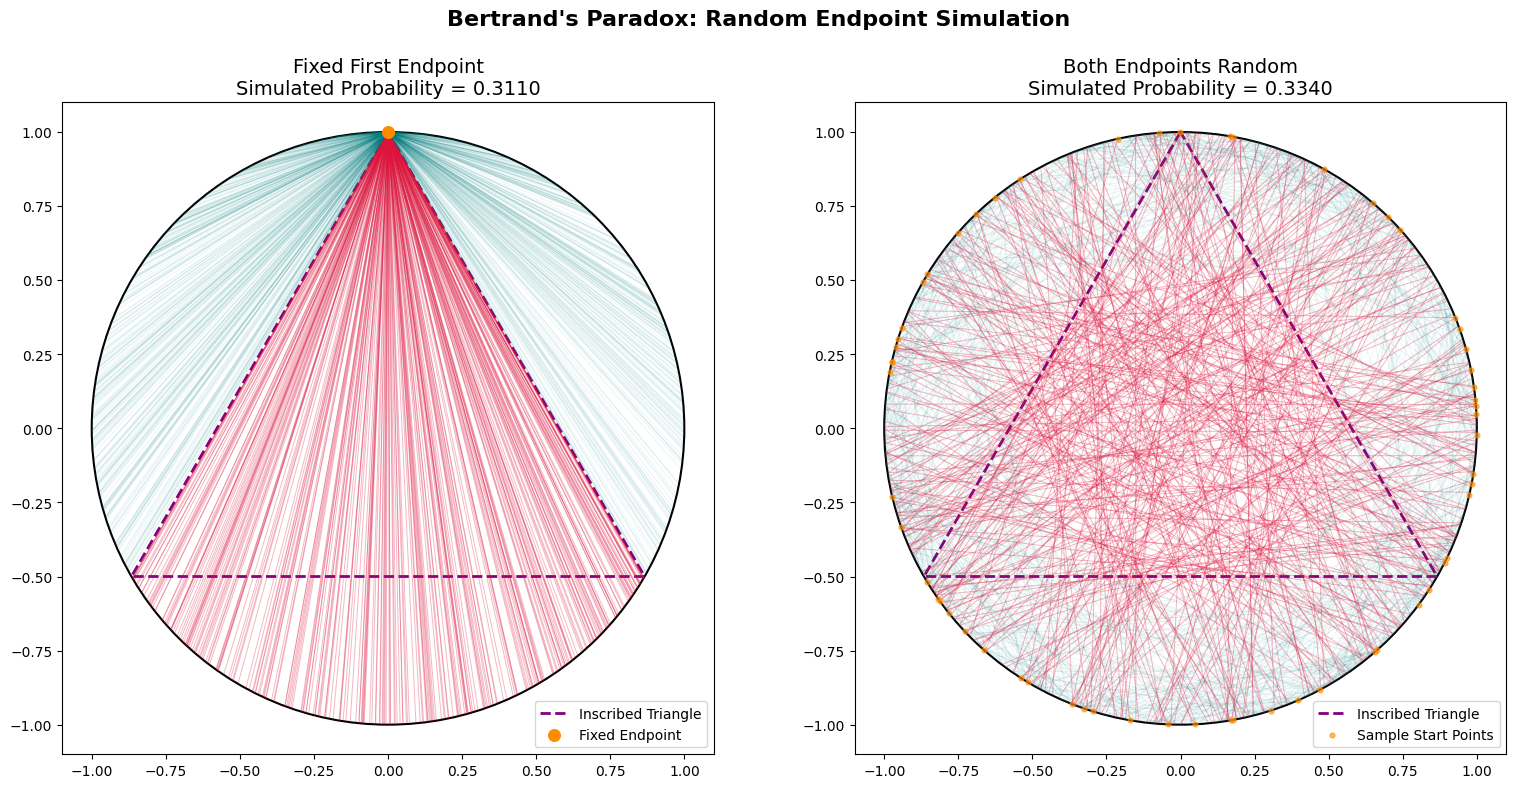

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection

def bertrand_endpoint_simulation(number_of_chords=1000):
    radius = 1.0
    triangle_side = np.sqrt(3) * radius

    fig, axes = plt.subplots(1, 2, figsize=(16, 8))

    # Method 1: one endpoint fixed
    fixed_point = np.array([0, radius])

    random_angles = np.random.uniform(0, 2*np.pi, number_of_chords)

    end_x = radius * np.cos(random_angles)
    end_y = radius * np.sin(random_angles)

    chord_lengths_fixed = np.sqrt((end_x - fixed_point[0])**2 + (end_y - fixed_point[1])**2)

    chord_lines_fixed = [
        [(fixed_point[0], fixed_point[1]), (end_x[i], end_y[i])]
        for i in range(number_of_chords)
    ]

    probability_fixed = np.mean(chord_lengths_fixed > triangle_side)

    # Method 2: both endpoints random
    angle_a = np.random.uniform(0, 2*np.pi, number_of_chords)
    angle_b = np.random.uniform(0, 2*np.pi, number_of_chords)

    start_x = radius * np.cos(angle_a)
    start_y = radius * np.sin(angle_a)

    final_x = radius * np.cos(angle_b)
    final_y = radius * np.sin(angle_b)

    chord_lengths_random = np.sqrt((final_x - start_x)**2 + (final_y - start_y)**2)

    chord_lines_random = [
        [(start_x[i], start_y[i]), (final_x[i], final_y[i])]
        for i in range(number_of_chords)
    ]

    probability_random = np.mean(chord_lengths_random > triangle_side)

    # Common plot settings
    plot_data = [
        (
            axes[0],
            chord_lines_fixed,
            chord_lengths_fixed,
            probability_fixed,
            "Fixed First Endpoint",
            True
        ),
        (
            axes[1],
            chord_lines_random,
            chord_lengths_random,
            probability_random,
            "Both Endpoints Random",
            False
        )
    ]

    for ax, chord_lines, lengths, probability, title, fixed_case in plot_data:

        # Circle boundary
        boundary = plt.Circle(
            (0, 0),
            radius,
            edgecolor="black",
            fill=False,
            linewidth=1.5
        )
        ax.add_patch(boundary)

        # Inscribed equilateral triangle
        triangle_angles = np.deg2rad([90, 210, 330, 90])

        ax.plot(
            radius * np.cos(triangle_angles),
            radius * np.sin(triangle_angles),
            linestyle="--",
            linewidth=2,
            color="purple",
            label="Inscribed Triangle"
        )

        # Colour chords according to length condition
        line_colours = [
            "crimson" if length > triangle_side else "teal"
            for length in lengths
        ]

        line_alpha = [
            0.30 if length > triangle_side else 0.08
            for length in lengths
        ]

        chord_collection = LineCollection(
            chord_lines,
            colors=line_colours,
            alpha=line_alpha,
            linewidths=0.7
        )

        ax.add_collection(chord_collection)

        # Endpoint markers
        if fixed_case:
            ax.scatter(
                fixed_point[0],
                fixed_point[1],
                color="darkorange",
                s=70,
                zorder=5,
                label="Fixed Endpoint"
            )
        else:
            ax.scatter(
                start_x[:60],
                start_y[:60],
                color="darkorange",
                s=12,
                alpha=0.6,
                zorder=5,
                label="Sample Start Points"
            )

        ax.set_title(
            f"{title}\nSimulated Probability = {probability:.4f}",
            fontsize=14
        )

        ax.set_xlim(-1.1, 1.1)
        ax.set_ylim(-1.1, 1.1)
        ax.set_aspect("equal", adjustable="box")
        ax.legend(loc="lower right")

    plt.suptitle(
        "Bertrand's Paradox: Random Endpoint Simulation",
        fontsize=16,
        fontweight="bold"
    )

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()


bertrand_endpoint_simulation(1000)

# 2. Random Radial Distance Method

In this method, a chord is generated by first selecting a radius of the circle and then choosing a random point along that radius. A chord is constructed perpendicular to the radius through the selected point.

Because the circle is symmetric, the orientation of the chosen radius does not affect the probability calculation. Therefore, we only need to consider the distance \(d\) measured from the center of the circle to the selected point on the radius.

The value of \(d\) can vary from

$$
0 \leq d \leq R
$$

Let \(E\) denote the event that the generated chord is longer than the side length of the inscribed equilateral triangle.

From circle geometry, the chord satisfies this condition only when the selected point lies within a distance of

$$
\frac{R}{2}
$$

from the center. This distance corresponds to the apothem of the equilateral triangle.

Hence, the event region can be written as

$$
E=\left\{ d : 0 \leq d \leq \frac{R}{2} \right\}
$$

Since the point is selected uniformly along the radius:

* Total sample range:

$$
\text{Range}(\Omega)=R
$$

* Favorable range:

$$
\text{Range}(E)=\frac{R}{2}
$$

Therefore,

$$
P(E)=\frac{\text{Range}(E)}{\text{Range}(\Omega)}
$$

$$
P(E)=\frac{R/2}{R}
$$

Simplifying,

$$
P(E)=\frac{1}{2}
$$

Thus, the probability becomes

$$
P(E)=0.5
$$

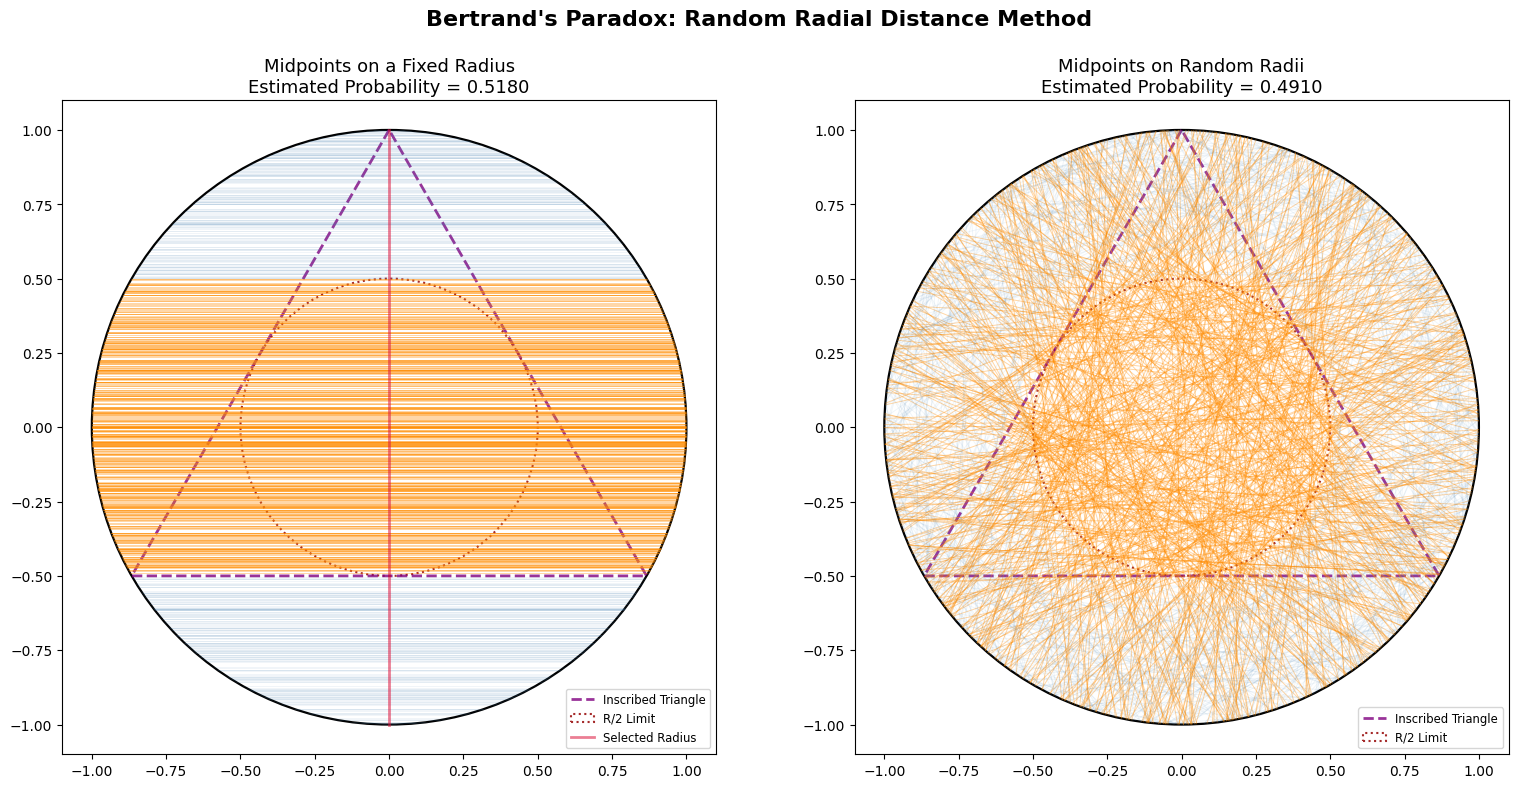

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection

def bertrand_radial_distance_simulation(sample_count=1000):
    radius = 1.0
    triangle_side_length = radius * np.sqrt(3)

    fig, axes = plt.subplots(1, 2, figsize=(16, 8))

    # Method 2A: midpoints selected on one fixed vertical radius
    midpoint_y = np.random.uniform(-radius, radius, sample_count)
    distance_from_center_1 = np.abs(midpoint_y)

    half_chord_1 = np.sqrt(np.maximum(0, radius**2 - distance_from_center_1**2))

    chords_fixed_radius = [
        [(-half_chord_1[i], midpoint_y[i]), (half_chord_1[i], midpoint_y[i])]
        for i in range(sample_count)
    ]

    chord_lengths_1 = 2 * half_chord_1
    probability_1 = np.mean(chord_lengths_1 > triangle_side_length)

    # Method 2B: midpoints selected along randomly oriented radii
    random_angle = np.random.uniform(0, 2*np.pi, sample_count)
    radial_distance = np.random.uniform(0, radius, sample_count)

    midpoint_x = radial_distance * np.cos(random_angle)
    midpoint_y_2 = radial_distance * np.sin(random_angle)

    direction_x = -np.sin(random_angle)
    direction_y = np.cos(random_angle)

    half_chord_2 = np.sqrt(np.maximum(0, radius**2 - radial_distance**2))

    chords_all_radii = [
        [
            (midpoint_x[i] + direction_x[i] * half_chord_2[i],
             midpoint_y_2[i] + direction_y[i] * half_chord_2[i]),
            (midpoint_x[i] - direction_x[i] * half_chord_2[i],
             midpoint_y_2[i] - direction_y[i] * half_chord_2[i])
        ]
        for i in range(sample_count)
    ]

    chord_lengths_2 = 2 * half_chord_2
    probability_2 = np.mean(chord_lengths_2 > triangle_side_length)

    plot_information = [
        (
            axes[0],
            chords_fixed_radius,
            chord_lengths_1,
            probability_1,
            "Midpoints on a Fixed Radius",
            True
        ),
        (
            axes[1],
            chords_all_radii,
            chord_lengths_2,
            probability_2,
            "Midpoints on Random Radii",
            False
        )
    ]

    for ax, chords, lengths, probability, title, show_radius in plot_information:

        outer_circle = plt.Circle(
            (0, 0),
            radius,
            edgecolor="black",
            fill=False,
            linewidth=1.6
        )
        ax.add_patch(outer_circle)

        triangle_angles = np.deg2rad([90, 210, 330, 90])

        ax.plot(
            radius * np.cos(triangle_angles),
            radius * np.sin(triangle_angles),
            linestyle="--",
            linewidth=2,
            color="purple",
            alpha=0.8,
            label="Inscribed Triangle"
        )

        half_radius_circle = plt.Circle(
            (0, 0),
            radius / 2,
            edgecolor="brown",
            fill=False,
            linestyle=":",
            linewidth=1.5,
            label="R/2 Limit"
        )
        ax.add_patch(half_radius_circle)

        chord_colours = [
            "darkorange" if length > triangle_side_length else "steelblue"
            for length in lengths
        ]

        chord_alpha = [
            0.35 if length > triangle_side_length else 0.08
            for length in lengths
        ]

        chord_collection = LineCollection(
            chords,
            colors=chord_colours,
            alpha=chord_alpha,
            linewidths=0.7
        )
        ax.add_collection(chord_collection)

        if show_radius:
            ax.plot(
                [0, 0],
                [-radius, radius],
                color="crimson",
                linewidth=2,
                alpha=0.55,
                label="Selected Radius"
            )

        ax.set_title(
            f"{title}\nEstimated Probability = {probability:.4f}",
            fontsize=13
        )

        ax.set_xlim(-1.1, 1.1)
        ax.set_ylim(-1.1, 1.1)
        ax.set_aspect("equal", adjustable="box")
        ax.legend(loc="lower right", fontsize="small")

    plt.suptitle(
        "Bertrand's Paradox: Random Radial Distance Method",
        fontsize=16,
        fontweight="bold"
    )

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()


bertrand_radial_distance_simulation(1000)

# 3. Random Midpoint Method

In this method, a chord is constructed by first selecting a random point inside the circle and considering that point as the midpoint of the chord. Except for the center, each midpoint uniquely determines a chord inside the circle.

To determine when the chord becomes longer than the side length of the inscribed equilateral triangle, we examine the position of the midpoint \(P\).

From geometry, the chord will satisfy the required condition only if the midpoint lies sufficiently close to the center of the circle. More precisely, the midpoint must lie inside a smaller concentric circle whose radius is

$$
\frac{R}{2}
$$

If the midpoint lies outside this region, the generated chord will be shorter than the side of the equilateral triangle.

Let \(E\) denote the event that the chord length exceeds the side length of the inscribed triangle.

Since the midpoint is selected uniformly over the entire circular region, the probability is determined using an area ratio.

* Area of the complete sample space:

$$
\text{Area}(\Omega)=\pi R^2
$$

* Area of the favourable region:

$$
\text{Area}(E)=\pi \left(\frac{R}{2}\right)^2
$$

which simplifies to

$$
\text{Area}(E)=\frac{\pi R^2}{4}
$$

Therefore,

$$
P(E)=\frac{\text{Area}(E)}{\text{Area}(\Omega)}
$$

$$
P(E)=\frac{\pi R^2/4}{\pi R^2}
$$

Simplifying,

$$
P(E)=\frac{1}{4}
$$

Thus, the probability becomes

$$
P(E)=0.25
$$

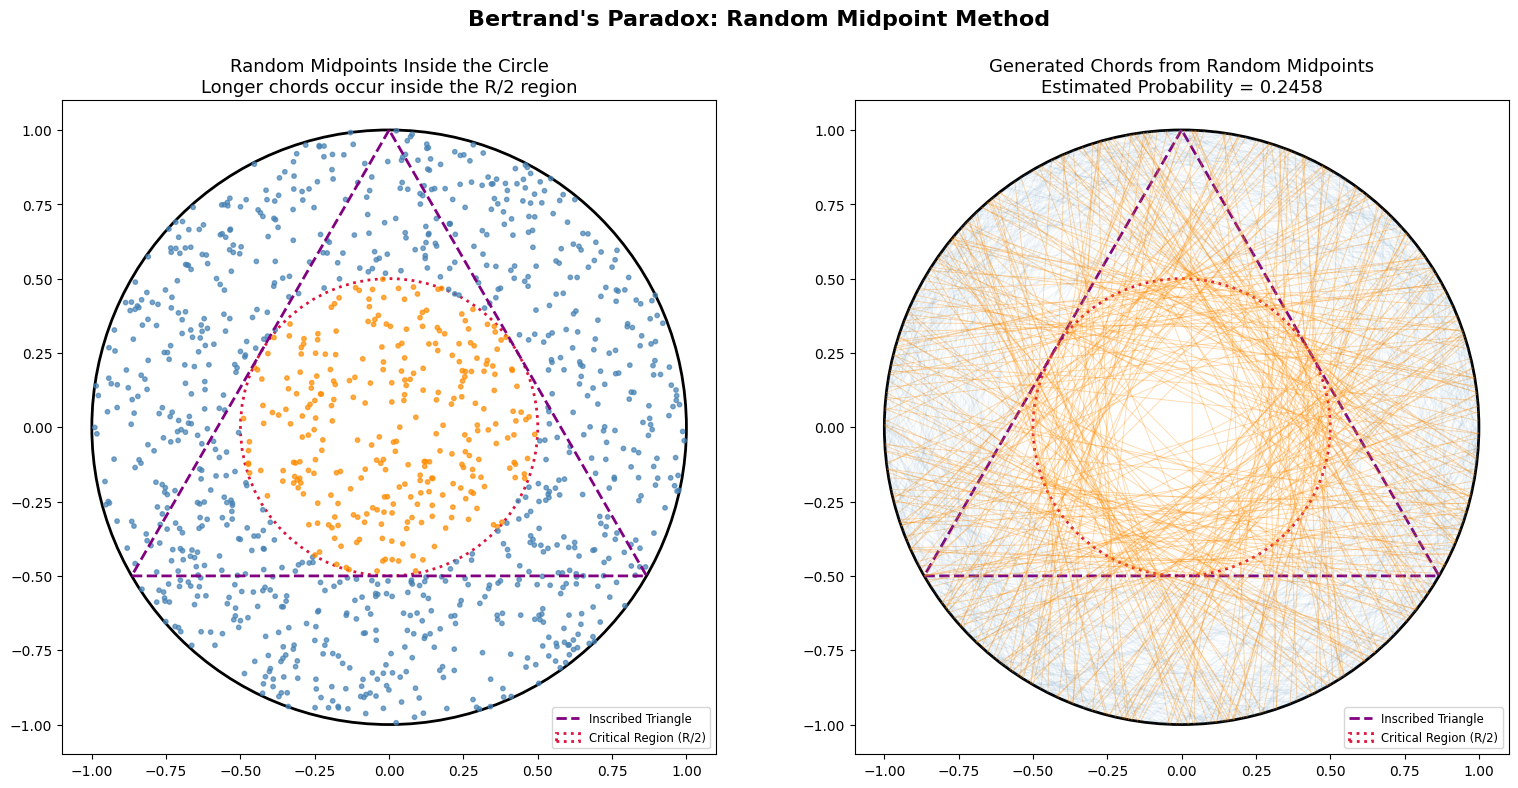

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection

def bertrand_midpoint_area_simulation(sample_total=1200):
    radius = 1.0
    triangle_side = radius * np.sqrt(3)

    fig, axes = plt.subplots(1, 2, figsize=(16, 8))

    # Random midpoint selection inside the circle
    # sqrt is used so that points are uniformly distributed over the area
    midpoint_radius = radius * np.sqrt(np.random.rand(sample_total))
    midpoint_angle = np.random.uniform(0, 2*np.pi, sample_total)

    # Midpoint coordinates
    mid_x = midpoint_radius * np.cos(midpoint_angle)
    mid_y = midpoint_radius * np.sin(midpoint_angle)

    # Direction perpendicular to the radius
    perp_x = -np.sin(midpoint_angle)
    perp_y = np.cos(midpoint_angle)

    # Half length of each chord
    half_length = np.sqrt(np.maximum(0, radius**2 - midpoint_radius**2))

    # Chord endpoints
    chord_x1 = mid_x + perp_x * half_length
    chord_y1 = mid_y + perp_y * half_length

    chord_x2 = mid_x - perp_x * half_length
    chord_y2 = mid_y - perp_y * half_length

    chord_lengths = 2 * half_length

    estimated_probability = np.mean(chord_lengths > triangle_side)

    point_colours = [
        "darkorange" if length > triangle_side else "steelblue"
        for length in chord_lengths
    ]

    for ax, show_midpoints in zip(axes, [True, False]):

        # Main circle
        outer_circle = plt.Circle(
            (0, 0),
            radius,
            edgecolor="black",
            fill=False,
            linewidth=2
        )
        ax.add_patch(outer_circle)

        # Inscribed equilateral triangle
        triangle_angles = np.deg2rad([90, 210, 330, 90])

        ax.plot(
            radius * np.cos(triangle_angles),
            radius * np.sin(triangle_angles),
            linestyle="--",
            linewidth=2,
            color="purple",
            label="Inscribed Triangle"
        )

        # Critical inner circle with radius R/2
        critical_circle = plt.Circle(
            (0, 0),
            radius / 2,
            edgecolor="crimson",
            fill=False,
            linestyle=":",
            linewidth=2,
            label="Critical Region (R/2)"
        )
        ax.add_patch(critical_circle)

        if show_midpoints:
            ax.scatter(
                mid_x,
                mid_y,
                c=point_colours,
                s=10,
                alpha=0.7
            )

            ax.set_title(
                "Random Midpoints Inside the Circle\n"
                "Longer chords occur inside the R/2 region",
                fontsize=13
            )

        else:
            chord_segments = [
                [(chord_x1[i], chord_y1[i]), (chord_x2[i], chord_y2[i])]
                for i in range(sample_total)
            ]

            chord_alpha = [
                0.30 if length > triangle_side else 0.05
                for length in chord_lengths
            ]

            chord_collection = LineCollection(
                chord_segments,
                colors=point_colours,
                alpha=chord_alpha,
                linewidths=0.7
            )

            ax.add_collection(chord_collection)

            ax.set_title(
                f"Generated Chords from Random Midpoints\n"
                f"Estimated Probability = {estimated_probability:.4f}",
                fontsize=13
            )

        ax.set_xlim(-1.1, 1.1)
        ax.set_ylim(-1.1, 1.1)
        ax.set_aspect("equal", adjustable="box")
        ax.legend(loc="lower right", fontsize="small")

    plt.suptitle(
        "Bertrand's Paradox: Random Midpoint Method",
        fontsize=16,
        fontweight="bold"
    )

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()


bertrand_midpoint_area_simulation(1200)

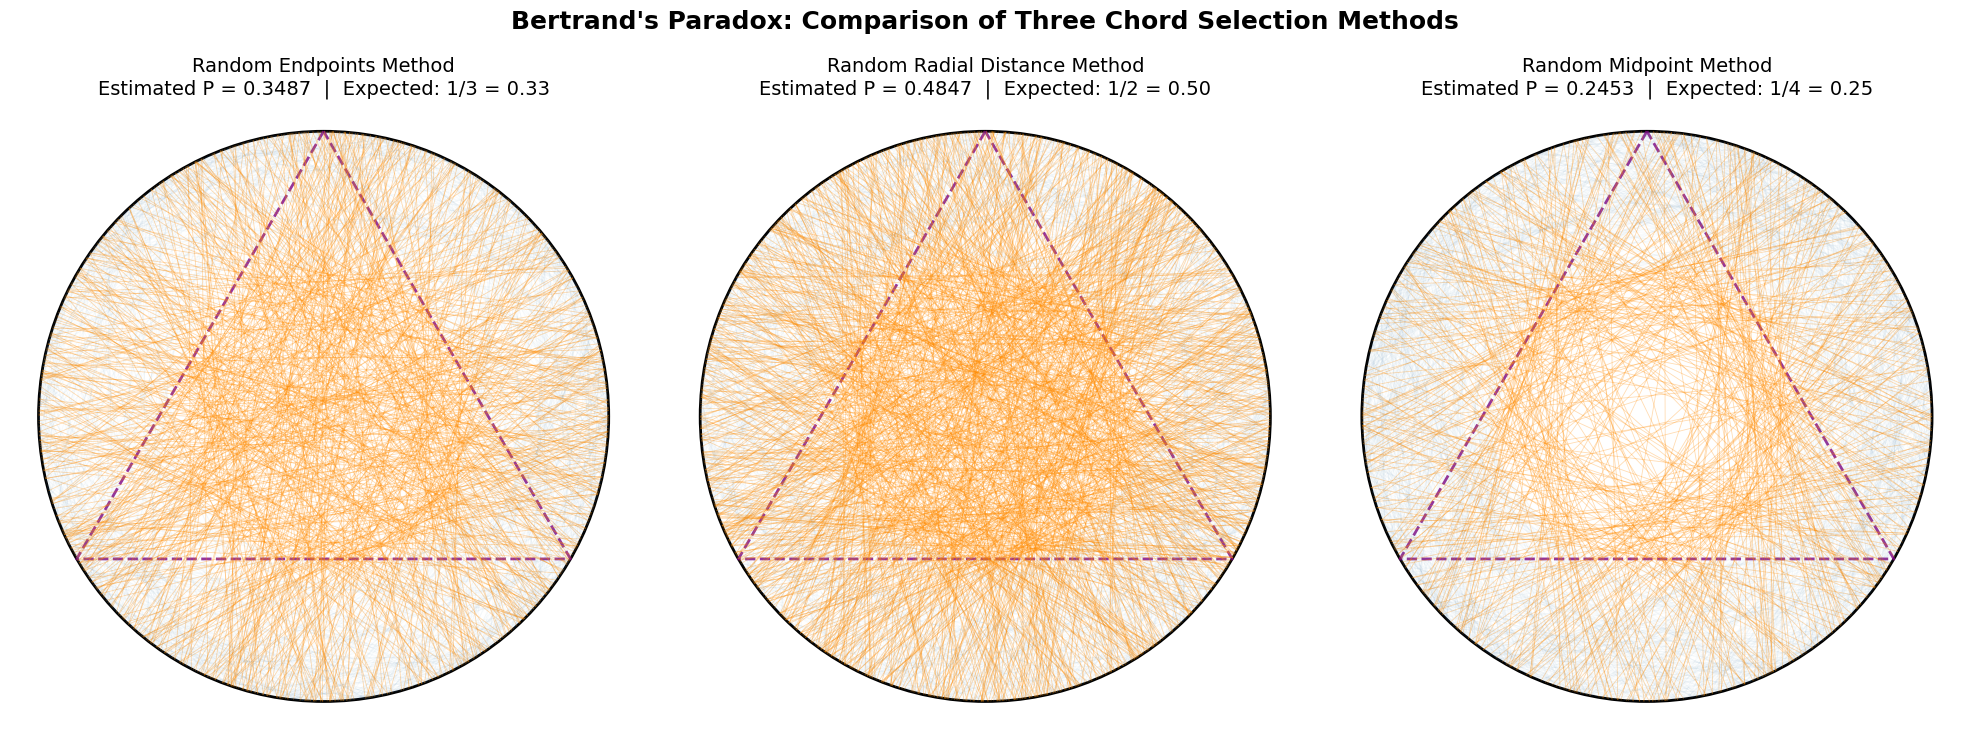

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection

def compare_bertrand_methods(sample_size=1500):
    radius = 1.0
    triangle_side = radius * np.sqrt(3)

    fig, axes = plt.subplots(1, 3, figsize=(20, 7))

    # Method 1: Random endpoints
    angle_1 = np.random.uniform(0, 2*np.pi, sample_size)
    angle_2 = np.random.uniform(0, 2*np.pi, sample_size)

    x_start = radius * np.cos(angle_1)
    y_start = radius * np.sin(angle_1)

    x_end = radius * np.cos(angle_2)
    y_end = radius * np.sin(angle_2)

    lengths_endpoint = np.sqrt((x_end - x_start)**2 + (y_end - y_start)**2)

    chords_endpoint = [
        [(x_start[i], y_start[i]), (x_end[i], y_end[i])]
        for i in range(sample_size)
    ]

    probability_endpoint = np.mean(lengths_endpoint > triangle_side)

    # Method 2: Random radial distance
    radius_angle = np.random.uniform(0, 2*np.pi, sample_size)
    center_distance = np.random.uniform(0, radius, sample_size)

    mid_x_2 = center_distance * np.cos(radius_angle)
    mid_y_2 = center_distance * np.sin(radius_angle)

    perp_x_2 = -np.sin(radius_angle)
    perp_y_2 = np.cos(radius_angle)

    half_chord_2 = np.sqrt(np.maximum(0, radius**2 - center_distance**2))

    chords_radius = [
        [
            (mid_x_2[i] + perp_x_2[i] * half_chord_2[i],
             mid_y_2[i] + perp_y_2[i] * half_chord_2[i]),
            (mid_x_2[i] - perp_x_2[i] * half_chord_2[i],
             mid_y_2[i] - perp_y_2[i] * half_chord_2[i])
        ]
        for i in range(sample_size)
    ]

    lengths_radius = 2 * half_chord_2
    probability_radius = np.mean(lengths_radius > triangle_side)

    # Method 3: Random midpoint
    midpoint_r = radius * np.sqrt(np.random.rand(sample_size))
    midpoint_theta = np.random.uniform(0, 2*np.pi, sample_size)

    mid_x_3 = midpoint_r * np.cos(midpoint_theta)
    mid_y_3 = midpoint_r * np.sin(midpoint_theta)

    perp_x_3 = -np.sin(midpoint_theta)
    perp_y_3 = np.cos(midpoint_theta)

    half_chord_3 = np.sqrt(np.maximum(0, radius**2 - midpoint_r**2))

    chords_midpoint = [
        [
            (mid_x_3[i] + perp_x_3[i] * half_chord_3[i],
             mid_y_3[i] + perp_y_3[i] * half_chord_3[i]),
            (mid_x_3[i] - perp_x_3[i] * half_chord_3[i],
             mid_y_3[i] - perp_y_3[i] * half_chord_3[i])
        ]
        for i in range(sample_size)
    ]

    lengths_midpoint = 2 * half_chord_3
    probability_midpoint = np.mean(lengths_midpoint > triangle_side)

    plot_titles = [
        "Random Endpoints Method",
        "Random Radial Distance Method",
        "Random Midpoint Method"
    ]

    simulated_probabilities = [
        probability_endpoint,
        probability_radius,
        probability_midpoint
    ]

    chord_sets = [
        chords_endpoint,
        chords_radius,
        chords_midpoint
    ]

    length_sets = [
        lengths_endpoint,
        lengths_radius,
        lengths_midpoint
    ]

    theoretical_values = [
        "1/3 = 0.33",
        "1/2 = 0.50",
        "1/4 = 0.25"
    ]

    triangle_angles = np.deg2rad([90, 210, 330, 90])

    for ax, title, prob, chords, lengths, target in zip(
        axes,
        plot_titles,
        simulated_probabilities,
        chord_sets,
        length_sets,
        theoretical_values
    ):

        outer_circle = plt.Circle(
            (0, 0),
            radius,
            edgecolor="black",
            fill=False,
            linewidth=2
        )
        ax.add_patch(outer_circle)

        ax.plot(
            radius * np.cos(triangle_angles),
            radius * np.sin(triangle_angles),
            linestyle="--",
            linewidth=2,
            color="purple",
            alpha=0.8
        )

        chord_colours = [
            "darkorange" if length > triangle_side else "steelblue"
            for length in lengths
        ]

        chord_alpha = [
            0.30 if length > triangle_side else 0.04
            for length in lengths
        ]

        chord_collection = LineCollection(
            chords,
            colors=chord_colours,
            alpha=chord_alpha,
            linewidths=0.6
        )

        ax.add_collection(chord_collection)

        ax.set_title(
            f"{title}\nEstimated P = {prob:.4f}  |  Expected: {target}",
            fontsize=14
        )

        ax.set_xlim(-1.1, 1.1)
        ax.set_ylim(-1.1, 1.1)
        ax.set_aspect("equal", adjustable="box")
        ax.axis("off")

    plt.suptitle(
        "Bertrand's Paradox: Comparison of Three Chord Selection Methods",
        fontsize=18,
        fontweight="bold",
        y=1.05
    )

    plt.tight_layout()
    plt.show()


compare_bertrand_methods(1500)

# Conclusion: Understanding Bertrand’s Paradox

From the three different methods, we obtained three different probabilities:

$$
\frac{1}{3}, \quad \frac{1}{2}, \quad \frac{1}{4}
$$

The reason for these different answers is that each method defines randomness in a different way. As a result, the overall distribution pattern of the generated chords changes from one method to another.

In the first approach, randomness is based on the selection of endpoints on the circumference.  
In the second approach, randomness depends on the radial distance from the center.  
In the third approach, randomness is determined using the midpoint position inside the circle.

Because each model uses a different probability measure, the resulting chord distributions are not identical. Therefore, the probabilities obtained from the three methods are also different.

This demonstrates the central idea behind Bertrand’s Paradox:

> The phrase “chosen at random” is ambiguous unless the random selection procedure is clearly specified.

Hence, all three probabilities are mathematically valid within the context of their own sampling methods.

---

# **Q8) Probability of Being a Girl?**

* What is the probability that both children are girls, given that at least one of them is a girl?


there are 4 posibility means the sample space like is to be like
 * both 2 are boys (BB)
 * both 2 are girls (GG)
 * first one is boy next born is female (BG)
 * first born is female next is male(GB)


 so if we consider the sample space that like be $$\Omega = ({BB},{GG},{BG},{GB})$$

 in question they mension all the  thing has equal posipliblity so each one has 1/4 posibility

 so Probability that both childeren are female is one of this so we can stightley say that 0.25%

 $$P(Both girl) = 0.25$$


 *  **At least one girl**

 $$P(\text{At least one girl}) = N(\text{At least one girl})/N(\text{Sample space})$$
 $$ = 3/4$$

 $$P(\text{Both Girls} \mid \text{At Least One Girl}) =  \frac{P(\text{Both}\cap \text{At Least One Girl})}{P(\text{At Least One Girl})}$$

 $$ = (1/4)/(3/4)$$
  $$ = 1/3$$

---